In [1]:
import sys
sys.path.append("../../src/")
from project_imports import *
import numerical_quenches as nq
import TFIM_operators_from_states as op
import equilibrium_critical_correlations as eq
from numerical_quenches import g_linear_hold
colors=plt.get_cmap("tab10").colors
import kblock_ising_model as kb

plotting_dir = "/figs/"
def critical_times(gf,n):
    ek = 2*sqrt(gf**2+1)
    n_plot = np.arange(0,n)
    tns = (n_plot+1/2)*pi/ek
    return tns

In [3]:
rs= np.arange(1,20)
x=[eq.sigma_general([0,1,r,r+1]) for r in rs]

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


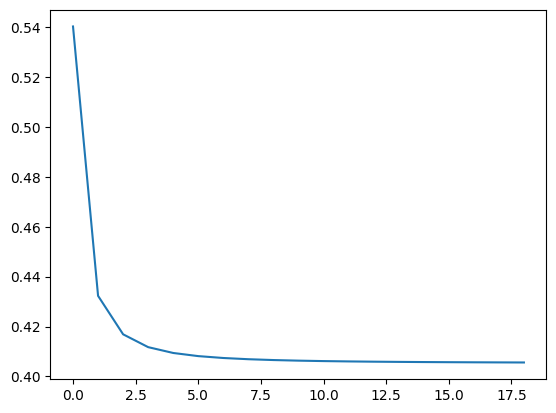

In [4]:
plot(x)

In [2]:
import numpy as np

def mutual_information_from_PP_P(PP, P, base=2):
    """
    Mutual information I(X;Y) for two identical Bernoulli variables
    defined by:

        P  = <P_ij> = <P_kl>
        PP = <P_ij P_kl>

    Parameters
    ----------
    PP : float or array
        Joint probability <P_ij P_kl>
    P : float or array
        Single-block probability <P_ij>
    base : {2, np.e}
        Logarithm base (2 → bits, e → nats)

    Returns
    -------
    I : float or array
        Mutual information
    """

    PP = np.asarray(PP)
    P = np.asarray(P)

    P11 = PP
    P10 = P - PP
    P01 = P - PP
    P00 = 1 - 2*P + PP

    def xlogx_over_y(x, y):
        mask = x > 0
        out = np.zeros_like(x, dtype=float)
        out[mask] = x[mask] * np.log(x[mask] / y[mask])
        return out

    if base == 2:
        log_factor = 1/np.log(2)
    else:
        log_factor = 1.0

    I = (
        xlogx_over_y(P11, P*P)
        + xlogx_over_y(P10, P*(1-P))
        + xlogx_over_y(P01, P*(1-P))
        + xlogx_over_y(P00, (1-P)*(1-P))
    )

    return I * log_factor

# Only One Spin x___x

In [40]:
def mutual_info_eq(ls,n):
    dat=[]
    for l in ls:
        PP=eq.P_n_correlations(n,l)
        P = eq.P_n(n)

        dat.append(mutual_information_from_PP_P(PP,P))
    return array(dat)
def mutual_info_kb(ls,n,U,k):
    dat=[]
    for l in ls:
        PP= kb.P_n_correlations(n,l,U,k)
        P = kb.P_n(n,U,k)

        dat.append(mutual_information_from_PP_P(PP,P))
    return array(dat)

def mutual_info_states(l,n,states):
    dat=[]
    for s in states:
        PP = op.Px_n_correlations(n,l,s)
        P = op.Px_n(n,s)
        dat.append(mutual_information_from_PP_P(PP,P))
    return array(dat)

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_22762/179770918.py:37: ComplexWarning: Casting complex values to real discards the imaginary part
  out[mask] = x[mask] * np.log(x[mask] / y[mask])


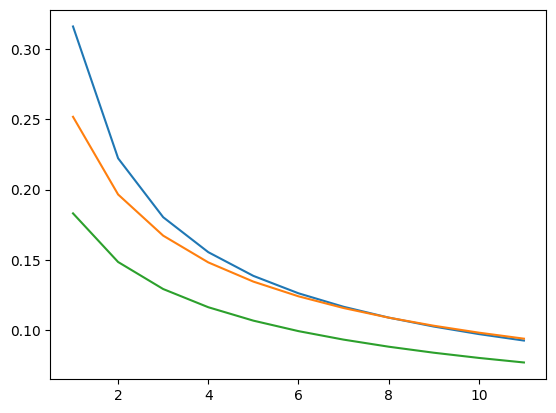

In [13]:
ls = np.arange(1,12)

plot(ls,mutual_info_eq(ls,1))
plot(ls,mutual_info_eq(ls,2))
plot(ls,mutual_info_eq(ls,3))

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_22762/179770918.py:37: ComplexWarning: Casting complex values to real discards the imaginary part
  out[mask] = x[mask] * np.log(x[mask] / y[mask])


Text(0.5, 0, 'l')

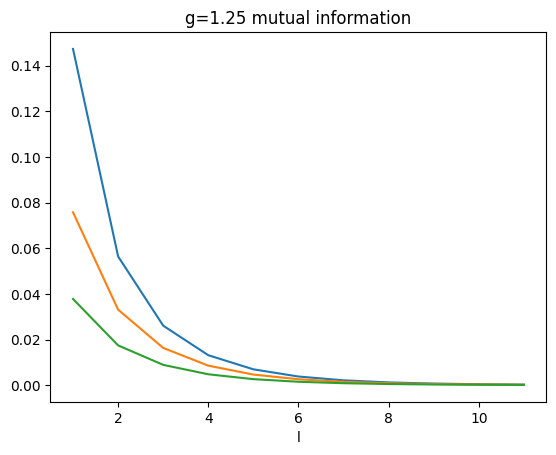

In [27]:
L = 50 
g = 1.25
ls = np.arange(1,12)

##############
k_vals= kb.k_vals(L)
U= kb.U(k_vals,g)
title(f"g={g} mutual information")
plot(ls,mutual_info_kb(ls,1,U,k_vals),label=1)
plot(ls,mutual_info_kb(ls,2,U,k_vals),label=2)
plot(ls,mutual_info_kb(ls,3,U,k_vals),label=3)
xlabel("l")

# Time Evolution

In [45]:
def g_quench(t,args):
    g = args
    return g


g0=0.2
g0=0.56


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_22762/179770918.py:37: ComplexWarning: Casting complex values to real discards the imaginary part
  out[mask] = x[mask] * np.log(x[mask] / y[mask])


g0=0.9199999999999999
g0=1.28
g0=1.64
g0=2.0


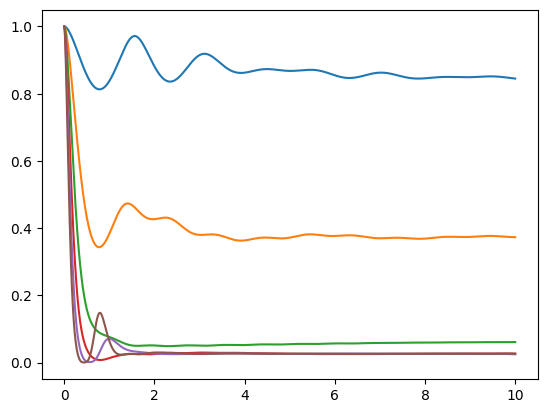

In [47]:
n = 1 
l = 3
for gf in np.linspace(0.2,2,6):
    psi0 = nq.groundstate(0,L)
    t_eval = np.linspace(0,10,1000)
    states = nq.states(L,t_eval,g_quench,gf,psi0)

    plot(t_eval,mutual_info_states(n,l,states))

g0=0.5


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_22762/179770918.py:37: ComplexWarning: Casting complex values to real discards the imaginary part
  out[mask] = x[mask] * np.log(x[mask] / y[mask])


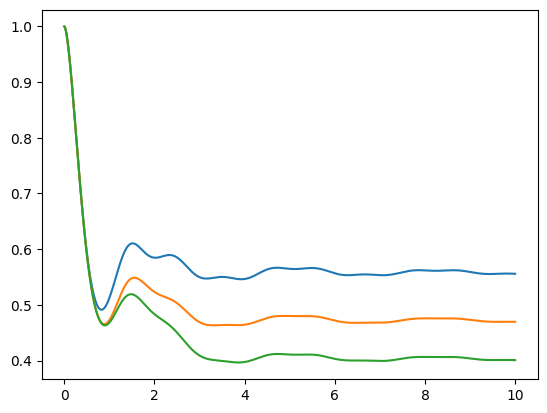

In [ ]:
n = 1 
l = 2
gf = .5
psi0 = nq.groundstate(0,L)
states = nq.states(L,t_eval,g_quench,gf,psi0)

for n in [1,2,3]:
    t_eval = np.linspace(0,10,1000)

    plot(t_eval,mutual_info_states(n,l,states))

g0=0.5


  0%|          | 0/3 [00:00<?, ?it/s]/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_22762/179770918.py:37: ComplexWarning: Casting complex values to real discards the imaginary part
  out[mask] = x[mask] * np.log(x[mask] / y[mask])
100%|██████████| 3/3 [00:02<00:00,  1.31it/s]


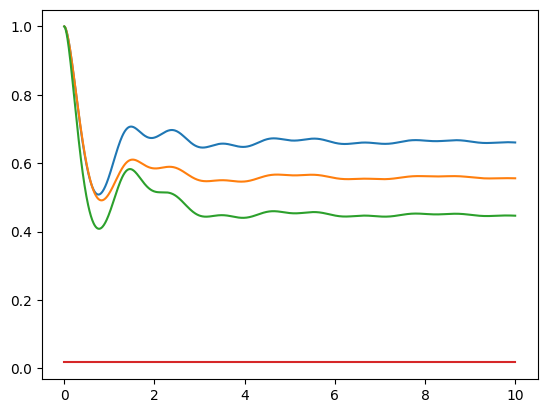

In [ ]:
n = 1 
gf = .5
psi0 = nq.groundstate(0,L)
psif = nq.groundstate(gf,L)
states = nq.states(L,t_eval,g_quench,gf,psi0)

for l in tqdm([1,2,3]):

    t_eval = np.linspace(0,10,1000)

    plot(t_eval,mutual_info_states(n,l,states))

plot(t_eval,-log(nq.overlap(states,psif))/L)